In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
import jax.numpy as jnp
from jax import vmap, grad, pmap
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)

import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)

import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
numpyro.set_host_device_count(jax.device_count())
from numpyro.handlers import seed, trace, condition
from numpyro.infer.reparam import LocScaleReparam, TransformReparam
from numpyro.infer import HMC, HMCECS, MCMC, NUTS, SA, SVI, Trace_ELBO, init_to_value
from numpyro.distributions.transforms import AffineTransform
import numpyro.distributions as dist

from jax import config
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import colossus 
import configobj
import copy
import yaml
from deepmerge import always_merger
import ast 
import jax_cosmo.background as bkgrd
import time
from jax_cosmo import Cosmology
from jax_cosmo.background import angular_diameter_distance, radial_comoving_distance
from astropy import constants as const

from godmax.base_class import base_class
from godmax.get_radial_profiles import Profiles
from godmax.get_Pkzs import get_Pkz
from godmax.get_Cls import get_Cl
from godmax.get_Xis import get_xi
from godmax.get_covs import get_cov




/tmp/ipykernel_968808/3085989222.py:7: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  platform = xla_bridge.get_backend().platform


1 1


In [2]:
probes_forecast = "ky,kk,gg,gy,gk,ge"
probes_forecast = probes_forecast.split(",")
sc_val = 8000

num_warmup = 2000
num_samples = 3000

num_chains= 4
max_tree_depth = 4
n_parallel = 1


In [3]:
probes_forecast


['ky', 'kk', 'gg', 'gy', 'gk', 'ge']

In [4]:
# generate code to call get_xi

# potential_energy -4916.635080802822
import yaml
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 

from deepmerge import always_merger
def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

default_data = read_yaml(abs_path_params + '/params_default.yaml')
# sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(default_data)
new_data = read_yaml(abs_path_params + '/Pge/params.yaml')
# new_data = read_yaml(abs_path_params + '/DESxACT/params_v0.yaml')
merged_data = always_merger.merge(default_data, new_data)

sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)

# analysis_dict['beam_fwhm_arcmin'] = 1.4
df_nz_comoving = np.loadtxt(abs_path_data + '/pge/comoving_nz_bgs_lrg_DESIY3_key_zall.txt')
zarray_comoving = df_nz_comoving[:,0]
nz_comoving_orig = df_nz_comoving[:,1]
indsel = np.where(zarray_comoving < 0.4)[0]
nz_comoving = np.zeros_like(zarray_comoving)
nz_comoving[indsel] = nz_comoving_orig[indsel]*1.0
indsel = np.where(zarray_comoving > 0.4)[0]
nz_comoving[indsel] = nz_comoving_orig[indsel]*1.0
analysis_dict['nbar_gal_comoving_zarray'] = zarray_comoving
analysis_dict['nbar_gal_comoving_val'] = nz_comoving



from scipy.interpolate import interp1d
# ks = np.geomspace(5e-2,50,15) # wavenumbers
ks = np.geomspace(3e-1,10,10) # wavenumbers
zedges = np.array([0.1, 0.4, 0.6, 0.8,1.1])
zarray_lens = np.linspace(0.001, 1.6, 100)
nbins_lens = len(zedges) - 1

cosmo_params = sim_params_dict.get('cosmo')
cosmo_jax = Cosmology(
            Omega_c=cosmo_params['Om0'] - cosmo_params['Ob0'],
            Omega_b=cosmo_params['Ob0'],
            h=cosmo_params['H0'] / 100.,
            sigma8=cosmo_params['sigma8'],
            n_s=cosmo_params['ns'],
            Omega_k=0.,
            w0=cosmo_params['w0'],
            wa=0.
            )
scale_fac_a_array = 1.0 / (1.0 + zarray_lens)
chi_array = radial_comoving_distance(cosmo_jax, scale_fac_a_array)
dchi_dz_array = (const.c.value * 1e-3) / bkgrd.H(cosmo_jax, scale_fac_a_array)
nz_comoving_interp = interp1d(zarray_comoving, nz_comoving, fill_value=1e-20, bounds_error=False)
nz_comoving_zarray = nz_comoving_interp(zarray_lens)
nz_zarray = nz_comoving_zarray * (chi_array**2 * dchi_dz_array)
nz_zarray = nz_zarray/(np.trapz(nz_zarray, zarray_lens))
nz_lens = {}
for jb in range(nbins_lens):
    nz_jb = np.zeros_like(nz_zarray)
    indsel = np.where((zarray_lens > zedges[jb]) & (zarray_lens < zedges[jb+1]))[0]
    nz_jb[indsel] = nz_zarray[indsel]
    norm_val = np.trapz(nz_jb, zarray_lens)
    nz_jb = nz_jb/norm_val
    nz_lens[jb] = nz_jb

nz_info_dict = {}
nz_info_dict['z_array_lens'] = zarray_lens
nz_info_dict['nbins_lens'] = nbins_lens
for ji in range(nz_info_dict['nbins_lens']):
    nz_info_dict['nz'+str(ji)] = np.maximum(nz_lens[ji], 1e-3)
analysis_dict['nz_lens_info_dict'] = nz_info_dict


from astropy.io import fits
df = fits.open(os.path.abspath(abs_path_data + '/forecast/lsst_simulate_Y1.fits'))
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array_source'] = z_array
nz_info_dict['nbins'] = 5
for ji in range(nz_info_dict['nbins']):
    nz_info_dict['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-4)
analysis_dict['nz_source_info_dict'] = nz_info_dict
other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])


analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]


analysis_dict['k_array_survey'] = jnp.array(ks / (sim_params_dict['cosmo']['H0']/100.))

lmin, lmax, dl_log_array = 80.0, 8800.0, 0.23025851
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
analysis_dict['dl_array_survey'] = jnp.array(dl_array)
analysis_dict['yy_noise_ell_fname'] = os.path.abspath(abs_path_data + '/pge/Noise_fid_yy_beamed_1p4arcmin.txt')

Ngals_bins = []
Vol_Gpc3 = []
z_cens = []
P0 = 9e3
fsky_DESIxDESI = analysis_dict['fsky_gg']
for jb in range(nbins_lens):
    nz_jb_only = np.copy(nz_comoving_zarray)
    indsel = np.where((zarray_lens < zedges[jb]) | (zarray_lens > zedges[jb+1]))[0]
    nz_jb_only[indsel] = 0.0
    nz_integrate = np.trapz(nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)

    ntot_jb = nz_integrate*4*np.pi*fsky_DESIxDESI
    Ngals_bins.append(ntot_jb)

    zmean = np.trapz(zarray_lens*nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)/nz_integrate
    z_cens.append(zmean)

    fsky_nz = np.ones_like(zarray_lens)
    fsky_nz[indsel] = 0.0
    fsky_nz_desi = fsky_nz * (nz_jb_only*P0/(1 + nz_jb_only*P0))**2
    h3 = (sim_params_dict['cosmo']['H0'] / 100.0)**3
    Vol_Gpc3_comoving = 4*np.pi*fsky_DESIxDESI*np.trapz(fsky_nz * (chi_array**2)*dchi_dz_array, zarray_lens)/(h3 * 1e9)   
    Vol_Gpc3_comoving_desi = 4*np.pi*fsky_DESIxDESI*np.trapz(fsky_nz_desi * (chi_array**2)*dchi_dz_array, zarray_lens)/(h3 * 1e9)   

    Vol_Gpc3.append(Vol_Gpc3_comoving_desi)
    print(zedges[jb], zedges[jb+1], 'Total galaxies = {:.2f}'.format(ntot_jb), ' Vol:', Vol_Gpc3_comoving_desi)
    # print('Bin {}: Total galaxies = {:.2f}'.format(jb, ntot_jb))
    

Ngals_bins, Vol_Gpc3, z_cens = np.array(Ngals_bins), np.array(Vol_Gpc3), np.array(z_cens)
    
    # Ngals_bins = 3.33*np.array([506905, 771875, 859824])
analysis_dict['nbar_lens_bins'] = Ngals_bins/(analysis_dict['fsky_gg']*41253*(60**2))

analysis_dict['symbolic_pk'] = True
analysis_dict['symbolic_hmf'] = True



/tmp/ipykernel_3478700/451449769.py:71: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  nz_zarray = nz_zarray/(np.trapz(nz_zarray, zarray_lens))
/tmp/ipykernel_3478700/451449769.py:77: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm_val = np.trapz(nz_jb, zarray_lens)


0.1 0.4 Total galaxies = 2094335.24  Vol: 5.48821108191444
0.4 0.6 Total galaxies = 2238124.27  Vol: 9.547174515203288
0.6 0.8 Total galaxies = 3190997.73  Vol: 13.706697159070595
0.8 1.1 Total galaxies = 3757239.75  Vol: 20.10026768637848


/tmp/ipykernel_3478700/451449769.py:125: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  nz_integrate = np.trapz(nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)
/tmp/ipykernel_3478700/451449769.py:130: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  zmean = np.trapz(zarray_lens*nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)/nz_integrate
/tmp/ipykernel_3478700/451449769.py:137: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Vol_Gpc3_comoving = 4*np.pi*fsky_DESIxDESI*np.trapz(fsky_nz * (chi_array**2)*dchi_dz_array, zarray_lens)/(h3 * 1e9)
/tmp/ipykernel_3478700/451449769.py:138: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrat

In [5]:
import pickle as pk

# df = pk.load(open(abs_path_data + '/pge/DV_fid_Cl_Pk_cov_mthresh_hod_v3.pk', 'rb'))
df = pk.load(open(abs_path_data + '/pge/DV_fid_Cl_Pk_cov_mthresh_hod_v5_symb_dataconsist.pk', 'rb'))
probes_all = df['probes']
ell_edges_left = df['edges_left']
ell_edges_right = df['edges_right']
ell_array = df['ell_array']
k_array = df['k_array']

bin_comb_all_wprobe = df['bin_comb_all_wprobe']

cov_total_orig = df['cov_mat']
Cl_total = df['Cl_Pk']

cov_total_orig_scaled = df['cov_mat_scaled']
Cl_total_scaled = df['dv_scaled']
scale_vec = jnp.array(df['scale_vec'])



In [6]:

import copy
from tqdm import tqdm
# from get_power_spectra import get_power_BCMP
get_power_BCMP_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)

nell = len(ell_array)
nk = len(analysis_dict['k_array_survey'])
Cl_all = jnp.zeros((cov_total_orig.shape[0]))
for jp1 in range(len(bin_comb_all_wprobe)):
    binwprobe1 = bin_comb_all_wprobe[jp1]
    probe1 = binwprobe1[0]
    bin_comb1 = binwprobe1[1]
    b1, b2 = bin_comb1[0], bin_comb1[1]
    if probe1 == 'ky':
        Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_y_tot_mat[:,b1-1])
    if probe1 == 'kk':
        Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_kappa_tot_mat[:,b1-1,b2-1])
    if probe1 == 'gg':
        Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_gal_tot_mat[:,b1-1,b2-1])
    if probe1 == 'gk':
        Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_kappa_tot_mat[:,b1-1,b2-1])
    if probe1 == 'gy':
        Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_y_tot_mat[:,b1-1])

edge_left_pge = ell_edges_left[-1]
Cl_all = Cl_all.at[edge_left_pge:edge_left_pge+nk].set(get_power_BCMP_test.Pge_tot_mat[0,:])
Cl_all = Cl_all.at[edge_left_pge+nk:edge_left_pge+2*nk].set(get_power_BCMP_test.Pge_tot_mat[1,:])
Cl_all = Cl_all.at[edge_left_pge+2*nk:edge_left_pge+3*nk].set(get_power_BCMP_test.Pge_tot_mat[2,:])
Cl_all = Cl_all.at[edge_left_pge+3*nk:edge_left_pge+4*nk].set(get_power_BCMP_test.Pge_tot_mat[3,:])

Cl_all = Cl_all * scale_vec


In [7]:
# Cl_all
# Cl_total
# Cl_all


In [8]:
# # bin_comb_all_wprobe

# # (Cl_total - Cl_all)/Cl_all
# # Cl_all
# pl.figure()
# pl.plot((Cl_total - Cl_all)/Cl_all)
# pl.ylim(-1, 1)



In [9]:
ell_min_max_dict = {'ky':[0, 11000], 'kk':[0, 11000], 'gg':[0, 11000], 'gk':[0, 11000], 'ge':[0, 11000]}

ell_sel_min = []
ell_sel_max = []
for jp in range(len(probes_forecast)):
    indp = probes_all.index(probes_forecast[jp])
    # print(indp)
    ell_sel_min.append(ell_edges_left[indp])
    ell_sel_max.append(ell_edges_right[indp])
    print(probes_forecast[jp], ell_sel_min[jp], ell_sel_max[jp])

ell_sel_min = np.array(ell_sel_min)
ell_sel_max = np.array(ell_sel_max)
argsort_min = np.argsort(ell_sel_min)
probes_forecast = [probes_forecast[jp] for jp in argsort_min]
ell_sel_min = ell_sel_min[argsort_min]
ell_sel_max = ell_sel_max[argsort_min]


import yaml

fname = abs_path_data + f'/pge/scale_cuts_all_probes_ellmax_{sc_val}_testcov.yaml'
with open(fname, 'r') as stream:
    sc_all = yaml.load(stream, Loader=yaml.SafeLoader)

ell_sel_all = []
# ell_count = 0
for jp in range(len(probes_forecast)):
    probe = probes_forecast[jp]
    sc_all_jp = sc_all[probe]
    ell_min_jp = ell_sel_min[jp]
    if probe != 'ge':
        for jsc in range(len(sc_all_jp)):
            key = list(sc_all_jp.keys())[jsc]
            scmin_jp_jsc = sc_all_jp[key][0]
            scmax_jp_jsc = sc_all_jp[key][1]
            indsel = np.where((ell_array >= scmin_jp_jsc) & (ell_array <= scmax_jp_jsc))[0]
            if len(indsel) > 0:
                ell_sel_all.append(np.arange(ell_min_jp + indsel[0], ell_min_jp + indsel[-1]+1))
                ell_min_jp += nell           
    else:
        for jsc in range(len(sc_all_jp)):
            key = list(sc_all_jp.keys())[jsc]
            scmin_jp_jsc = sc_all_jp[key][0]
            scmax_jp_jsc = sc_all_jp[key][1]
            indsel = np.where((k_array >= scmin_jp_jsc) & (k_array <= scmax_jp_jsc))[0]
            ell_sel_all.append(np.arange(ell_min_jp + indsel[0], ell_min_jp + indsel[-1]+1))
            ell_min_jp += nk
    ell_count = len(np.concatenate(ell_sel_all))
    print(probe, ell_count)
        # ell_max_jp = ell_sel_max[jp]
    # ell_sel_all.append(np.arange(ell_sel_min[jp], ell_sel_max[jp]))
ell_sel_all = np.concatenate(ell_sel_all)

# ell_sel_all = []
# for jp in range(len(probes_forecast)):
#     probe = probes_forecast[jp]
#     sc_all_jp = sc_all[probe]
#     ell_min_jp = ell_sel_min[jp]
#     if probe != 'ge':
#         for jsc in range(len(sc_all_jp)):
#             key = list(sc_all_jp.keys())[jsc]
#             scmin_jp_jsc = sc_all_jp[key][0]
#             scmax_jp_jsc = sc_all_jp[key][1]
#             indsel = np.where((ell_array >= scmin_jp_jsc) & (ell_array <= scmax_jp_jsc))[0]
#             ell_sel_all.append(np.arange(ell_min_jp + indsel[0], ell_min_jp + indsel[-1]+1))
#             ell_min_jp += nell           
#     else:
#         for jsc in range(len(sc_all_jp)):
#             key = list(sc_all_jp.keys())[jsc]
#             scmin_jp_jsc = sc_all_jp[key][0]
#             scmax_jp_jsc = sc_all_jp[key][1]
#             indsel = np.where((k_array >= scmin_jp_jsc) & (k_array <= scmax_jp_jsc))[0]
#             ell_sel_all.append(np.arange(ell_min_jp + indsel[0], ell_min_jp + indsel[-1]+1))
#             ell_min_jp += nk
#         # ell_max_jp = ell_sel_max[jp]
#     # ell_sel_all.append(np.arange(ell_sel_min[jp], ell_sel_max[jp]))
# ell_sel_all = np.concatenate(ell_sel_all)




ky 0 100
kk 100 400
gg 480 560
gy 400 480
gk 560 960
ge 960 990
ky 100
kk 400
gy 480
gg 560
gk 960
ge 988


In [10]:
# ell_array.shape
# len(ell_sel_all)
# ell_array
# ell_sel_all
import matplotlib.pyplot as pl
%matplotlib inline



In [11]:
# # bin_comb_all_wprobe

# # (Cl_total - Cl_all)/Cl_all
# # Cl_all
# pl.figure()
# # pl.plot(((Cl_total - Cl_all)/Cl_all)[ell_sel_all])
# # pl.plot(Cl_total[ell_sel_all])
# pl.plot(Cl_total[ell_sel_all])
# # pl.ylim(-1, 1)
# pl.yscale('log')




In [12]:
# data_vec = Cl_all[ell_sel_all]
data_vec = Cl_total_scaled[ell_sel_all]
# cov_total = cov_total_orig[ell_sel_all,:][:, ell_sel_all]
cov_total = cov_total_orig_scaled[ell_sel_all,:][:, ell_sel_all]
P_total = jnp.linalg.inv(cov_total)




In [13]:
import matplotlib.pyplot as pl
%matplotlib inline


In [14]:
# len(np.sqrt(jnp.diag(cov_total))), Cl_all.shape
get_power_BCMP_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)

nell = len(ell_array)
nk = len(analysis_dict['k_array_survey'])
Cl_th = jnp.zeros((cov_total_orig.shape[0]))
for jp1 in range(len(bin_comb_all_wprobe)):
    binwprobe1 = bin_comb_all_wprobe[jp1]
    probe1 = binwprobe1[0]
    bin_comb1 = binwprobe1[1]
    b1, b2 = bin_comb1[0], bin_comb1[1]
    if probe1 == 'ky':
        Cl_th = Cl_th.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_y_tot_mat[:,b1-1])
    if probe1 == 'kk':
        Cl_th = Cl_th.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_kappa_tot_mat[:,b1-1,b2-1])
    if probe1 == 'gg':
        Cl_th = Cl_th.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_gal_tot_mat[:,b1-1,b2-1])
    if probe1 == 'gk':
        Cl_th = Cl_th.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_kappa_tot_mat[:,b1-1,b2-1])
    if probe1 == 'gy':
        Cl_th = Cl_th.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_y_tot_mat[:,b1-1])

edge_left_pge = ell_edges_left[-1]
Cl_th = Cl_th.at[edge_left_pge:edge_left_pge+nk].set(get_power_BCMP_test.Pge_tot_mat[0,:])
Cl_th = Cl_th.at[edge_left_pge+nk:edge_left_pge+2*nk].set(get_power_BCMP_test.Pge_tot_mat[1,:])
Cl_th = Cl_th.at[edge_left_pge+2*nk:edge_left_pge+3*nk].set(get_power_BCMP_test.Pge_tot_mat[2,:])
Cl_th = Cl_th * scale_vec
mu = Cl_th[ell_sel_all]



In [15]:
# np.amin(mu), np.amax(mu)
np.all(np.isfinite(mu)), np.all(np.isfinite(data_vec)), np.all(np.isfinite(cov_total))


(np.True_, np.True_, np.True_)

In [16]:
# pl.figure()
# pl.errorbar(np.arange(len(data_vec)), data_vec, np.sqrt(jnp.diag(cov_total)), fmt='o', label='Cl_all', ms=0.1)
# pl.plot(np.arange(len(data_vec)), mu, label='Cl_th', color='red')
# # pl.plot(data_vec)
# pl.yscale('log')
# # pl.xlim(0, 100)



In [17]:
# len(ell_sel_all), len(data_vec), len(cov_total), len(Cl_all)




In [18]:
from numpyro.distributions.transforms import AffineTransform
import numpyro.distributions as dist
import numpyro
def Uniform(name, min_value, max_value):
    """ Creates a Uniform distribution in target range from a base
    distribution between [-3, 3]
    """
    s = (max_value - min_value) / 6.
    return numpyro.sample(
            name,
            dist.TransformedDistribution(
                dist.Uniform(-3., 3.),
                AffineTransform(min_value + 3.*s, s),
            ),
        )



In [19]:
with open(abs_path_params + '/Pge/priors.yaml', 'r') as file:
    data = yaml.safe_load(file)
prior_limits = {key: tuple(map(float, value.split())) for key, value in data['prior_uniform'].items()}
prior_gaussian = {key: tuple(map(float, value.split())) for key, value in data['prior_gaussian'].items()}

prior_min_all_dict, prior_max_all_dict = {}, {}
for key in prior_limits.keys():
    prior_min_all_dict[key] = prior_limits[key][0]
    prior_max_all_dict[key] = prior_limits[key][1]

prior_mu_all_dict, prior_sig_all_dict = {}, {}
for key in prior_gaussian.keys():
    prior_mu_all_dict[key] = prior_gaussian[key][0]
    prior_sig_all_dict[key] = prior_gaussian[key][1]
prior_delta_z_mu_all = jnp.array([prior_mu_all_dict['Delta_z_bias_bin1'], prior_mu_all_dict['Delta_z_bias_bin2'], prior_mu_all_dict['Delta_z_bias_bin3'], prior_mu_all_dict['Delta_z_bias_bin4']])
prior_delta_z_sig_all = jnp.array([prior_sig_all_dict['Delta_z_bias_bin1'], prior_sig_all_dict['Delta_z_bias_bin2'], prior_sig_all_dict['Delta_z_bias_bin3'], prior_sig_all_dict['Delta_z_bias_bin4']])
prior_mult_shear_mu_all = jnp.array([prior_mu_all_dict['mult_shear_bias_bin1'], prior_mu_all_dict['mult_shear_bias_bin2'], prior_mu_all_dict['mult_shear_bias_bin3'], prior_mu_all_dict['mult_shear_bias_bin4']])
prior_mult_shear_sig_all = jnp.array([prior_sig_all_dict['mult_shear_bias_bin1'], prior_sig_all_dict['mult_shear_bias_bin2'], prior_sig_all_dict['mult_shear_bias_bin3'], prior_sig_all_dict['mult_shear_bias_bin4']])


cosmo_params_vary_names = ['Om0', 'sigma8', 'Ob0', 'h', 'ns']
sims_params_vary_names_baryons = ['theta_ej_0','nu_theta_ej_z','nu_theta_ej_M', 'mu_beta', 'alpha_nt']
sims_params_vary_names_gals = ['log10M1_fshmr', 'log10M1_a_fshmr','gamma_fshmr','gamma_a_fshmr',  'delta_fshmr', 'delta_a_fshmr', 'siglogMstar_Ncen', 'alphasat_Nsat']
sims_params_vary_names = sims_params_vary_names_baryons + sims_params_vary_names_gals
IA_params_vary_names = ['A_IA', 'eta_IA']
mult_shear_vary_names = ['mult_shear_bias_bin1', 'mult_shear_bias_bin2', 'mult_shear_bias_bin3', 'mult_shear_bias_bin4', 'mult_shear_bias_bin5'] 
Delta_shear_vary_names = ['Delta_z_bias_bin1', 'Delta_z_bias_bin2', 'Delta_z_bias_bin3', 'Delta_z_bias_bin4', 'Delta_z_bias_bin5']
analysis_vary_names = []




In [20]:
import jax 
from tqdm import tqdm
import copy
import numpyro
import copy

def model():
    sim_params_dict_vary = copy.deepcopy(sim_params_dict)
    other_params_dict_vary = copy.deepcopy(other_params_dict)
    analysis_dict_vary = copy.deepcopy(analysis_dict)
    if len(cosmo_params_vary_names) > 0:
        for jp in range(len(cosmo_params_vary_names)):
            if cosmo_params_vary_names[jp] == 'h':
                fac = 100.
                cosmo_name = 'H0'
            else:
                fac = 1.
                cosmo_name = cosmo_params_vary_names[jp]
            prior_min_jp = prior_min_all_dict[cosmo_params_vary_names[jp]]
            prior_max_jp = prior_max_all_dict[cosmo_params_vary_names[jp]]
            sim_params_dict_vary['cosmo'][cosmo_name] = fac * Uniform(cosmo_params_vary_names[jp], prior_min_jp, prior_max_jp)

    if len(sims_params_vary_names) > 0:
        for jp in range(len(sims_params_vary_names)):
            prior_min_jp = prior_min_all_dict[sims_params_vary_names[jp]]
            prior_max_jp = prior_max_all_dict[sims_params_vary_names[jp]]
            sim_params_dict_vary[sims_params_vary_names[jp]] = Uniform(sims_params_vary_names[jp], prior_min_jp, prior_max_jp)
    
    if len(IA_params_vary_names) > 0:
        for jp in range(len(IA_params_vary_names)):
            prior_min_jp = prior_min_all_dict[IA_params_vary_names[jp]]
            prior_max_jp = prior_max_all_dict[IA_params_vary_names[jp]]
            other_params_dict_vary[IA_params_vary_names[jp]] = Uniform(IA_params_vary_names[jp], prior_min_jp, prior_max_jp)
        
    if len(prior_delta_z_mu_all) > 0:
        Delta_z_bias_array = numpyro.sample('Delta_z_bias_array', dist.Normal(prior_delta_z_mu_all, prior_delta_z_sig_all)) 
        other_params_dict_vary['Delta_z_bias_array'] = Delta_z_bias_array
    
    if len(prior_mult_shear_mu_all) > 0:
        mult_shear_bias_array = numpyro.sample('mult_shear_bias_array', dist.Normal(prior_mult_shear_mu_all, prior_mult_shear_sig_all))
        other_params_dict_vary['mult_shear_bias_array'] = mult_shear_bias_array
    
    if len(analysis_vary_names) > 0:
        for jp in range(len(analysis_vary_names)):
            prior_min_jp = prior_min_all_dict[analysis_vary_names[jp]]
            prior_max_jp = prior_max_all_dict[analysis_vary_names[jp]]
            analysis_dict_vary[analysis_vary_names[jp]] = Uniform(analysis_vary_names[jp], prior_min_jp, prior_max_jp)
    
    get_power_BCMP_test = get_Cl(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary)

    nell = len(ell_array)
    nk = len(analysis_dict['k_array_survey'])
    Cl_all = jnp.zeros((cov_total_orig.shape[0]))
    for jp1 in range(len(bin_comb_all_wprobe)):
        binwprobe1 = bin_comb_all_wprobe[jp1]
        probe1 = binwprobe1[0]
        bin_comb1 = binwprobe1[1]
        b1, b2 = bin_comb1[0], bin_comb1[1]
        if probe1 == 'ky':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_y_tot_mat[:,b1-1])
        if probe1 == 'kk':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_kappa_tot_mat[:,b1-1,b2-1])
        if probe1 == 'gg':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_gal_tot_mat[:,b1-1,b2-1])
        if probe1 == 'gk':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_kappa_tot_mat[:,b1-1,b2-1])
        if probe1 == 'gy':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_y_tot_mat[:,b1-1])

    edge_left_pge = ell_edges_left[-1]
    Cl_all = Cl_all.at[edge_left_pge:edge_left_pge+nk].set(get_power_BCMP_test.Pge_tot_mat[0,:])
    Cl_all = Cl_all.at[edge_left_pge+nk:edge_left_pge+2*nk].set(get_power_BCMP_test.Pge_tot_mat[1,:])
    Cl_all = Cl_all.at[edge_left_pge+2*nk:edge_left_pge+3*nk].set(get_power_BCMP_test.Pge_tot_mat[2,:])
    Cl_all = Cl_all * scale_vec
    mu = Cl_all[ell_sel_all]
    return numpyro.sample('cl', dist.MultivariateNormal(mu, 
                                                            # precision_matrix=P_total,
                                                            covariance_matrix=cov_total
                                                            ))



In [21]:
import numpyro
numpyro.set_host_device_count(4)
from numpyro.handlers import seed, trace, condition
# Now we condition the model on obervations
observed_model = condition(model, {'cl': data_vec})

import numpyro
from numpyro.infer.reparam import LocScaleReparam, TransformReparam

def config(x):
    if type(x['fn']) is dist.TransformedDistribution:
        return TransformReparam()
    elif type(x['fn']) is dist.Normal and ('decentered' not in x['name']):
        return LocScaleReparam(centered=0)
    else:
        return None

observed_model_reparam = numpyro.handlers.reparam(observed_model, config=config)



In [22]:
# data_vec.shape
# np.amin(data_vec), np.amax(data_vec), np.mean(data_vec), np.std(data_vec)
# jnp.amin(P_total), jnp.amax(P_total)


In [23]:
from numpyro.infer import HMC, HMCECS, MCMC, NUTS, SA, SVI, Trace_ELBO, init_to_value
num_warmup = 300
num_samples = 600
n_vectorized = 24
rng_key = jax.random.PRNGKey(42)
nuts_kernel = numpyro.infer.NUTS(observed_model_reparam,
                            step_size=2e-1, 
                            init_strategy=numpyro.infer.init_to_median,
                            dense_mass=True,
                            max_tree_depth=4
                            # forward_mode_differentiation=True
                            )

mcmc = numpyro.infer.MCMC(nuts_kernel, 
                        num_warmup=num_warmup, 
                        num_samples=num_samples,
                        num_chains=n_vectorized,
                        chain_method='vectorized',
                        #   chain_method='sequential',                          
                        progress_bar=True,
                        jit_model_args=True)

mcmc.run(
    rng_key,
    extra_fields=("potential_energy",),
)



sample: 100%|██████████| 900/900 [29:52<00:00,  1.99s/it]  


In [24]:
samps_all_dict = mcmc.get_samples()




In [25]:
import pickle as pk
# df = pk.load(open('/mnt/home/spandey/ceph/GODMAX/notebooks/ACTxDES/mcmc_gty_xip_xim_8000_8000_800.pkl','rb'))
# df['s'].shape
# df
samps = []
keys = []
for key in samps_all_dict:
    if ('base' not in key) and ('decentered' not in key) and ('log' not in key) and ('_log' not in key):
        # print(key, samps_all_dict[key].shape, len(samps_all_dict[key].shape))
        if len(samps) == 0:
            samps = samps_all_dict[key][:, None]
        else:
            if len(samps_all_dict[key].shape) > 1:
                samps = np.concatenate((samps, samps_all_dict[key]), axis=1)
            else:
                samps = np.concatenate((samps, samps_all_dict[key][:, None]), axis=1)
        if 'array' in key:
            for jb in range(samps_all_dict[key].shape[1]):
                keys.append(key + str(jb))
        else:
            keys.append(key)
samps = np.array(samps)


In [26]:
samps.shape, len(keys)


((14400, 25), 25)

In [27]:
# names



In [28]:
# # samps.shape
# df = pk.load(open('/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/chains_Apr/mcmc_v1_test.pkl','rb'))
# df


In [29]:
samps = np.array(samps)
import getdist
from getdist import plots, MCSamples
# names = ["x%s"%i for i in range(ndim)]
# labels =  ["x_%s"%i for i in range(ndim)]
names = keys
# labels = keys
print(samps.shape, len(names))
samples = MCSamples(samples=samps,names = names)



(14400, 25) 25
Removed no burn in


In [30]:
# samps


In [31]:
import matplotlib
%matplotlib inline




<Figure size 625x625 with 0 Axes>

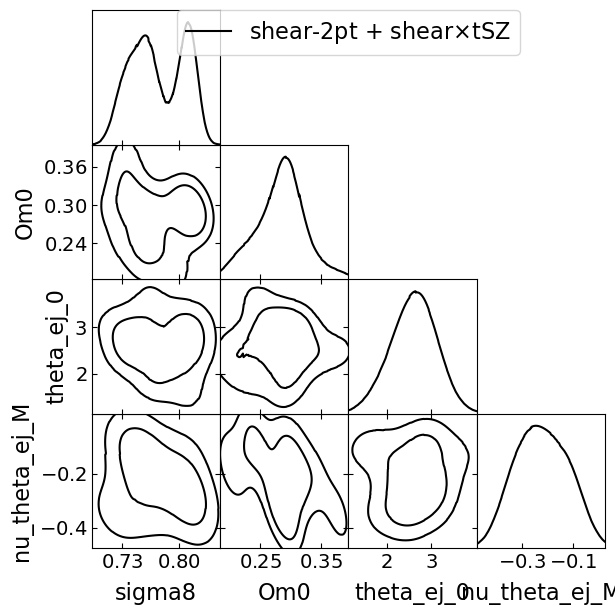

In [32]:
# params = ['Om0', 'theta_ej_0', 'nu_theta_ej_M',  'nu_theta_ej_z',  'mu_beta','A_IA', 'eta_IA', 'sigma8', 'alpha_ky', 'S8']
# params = ['Om0','A_IA', 'eta_IA', 'sigma8',  'S8', 'h', 'ns', 'Ob0','mult_shear_bias_array_3',  'Delta_z_bias_array_3']
g = plots.getSinglePlotter(width_inch=6.25, ratio=1.0)
# g.settings.auto_ticks = True
g.settings.axes_fontsize   = 18
g.settings.lab_fontsize    = 20
g.settings.legend_fontsize = 20
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 2

line_args = [{'lw':1.0,'color':'black'},{'lw':1.0, 'ls':'--' ,'color':'blue'},{'lw':1.0,'color':'red'},{'lw':0.1,'color':'orange'},{'lw':0.1,'color':'green'}]

contour_args = {'filled': True, 'alpha': 0.7}


# samps_all = get_MCsamps(ldir + 'mcmc_v10_widemuej_nzfix_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_8000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')
# samps_gty = get_MCsamps(ldir + 'mcmc_v10_widemuej_nzfix_probe_gty_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_8000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')
# samps_xipm = get_MCsamps(ldir + 'mcmc_v10_widemuej_nzfix_probe_xip_xim_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_8000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')
params = samples.getParamNames().getRunningNames()
# g = plots.get_subplot_plotter(width_inch=8)
g.triangle_plot([samples], ['sigma8', 'Om0', 'theta_ej_0', 'nu_theta_ej_M'], line_args=line_args, 
            contour_lws=[1.5, 1.5, 1.0], filled = [False, False,True, True, True], contour_colors = ['black','blue','red','orange','green'],
            ls=['-','--','','',''], legend_labels = [r'shear-2pt + shear$\times$tSZ',r'shear$\times$tSZ only',r'shear-2pt only'])
# save_plot_dir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# g.export(save_plot_dir  + 'contour_Om0_S8_nuejM_internal.pdf')
import matplotlib
%matplotlib inline
pl.show()





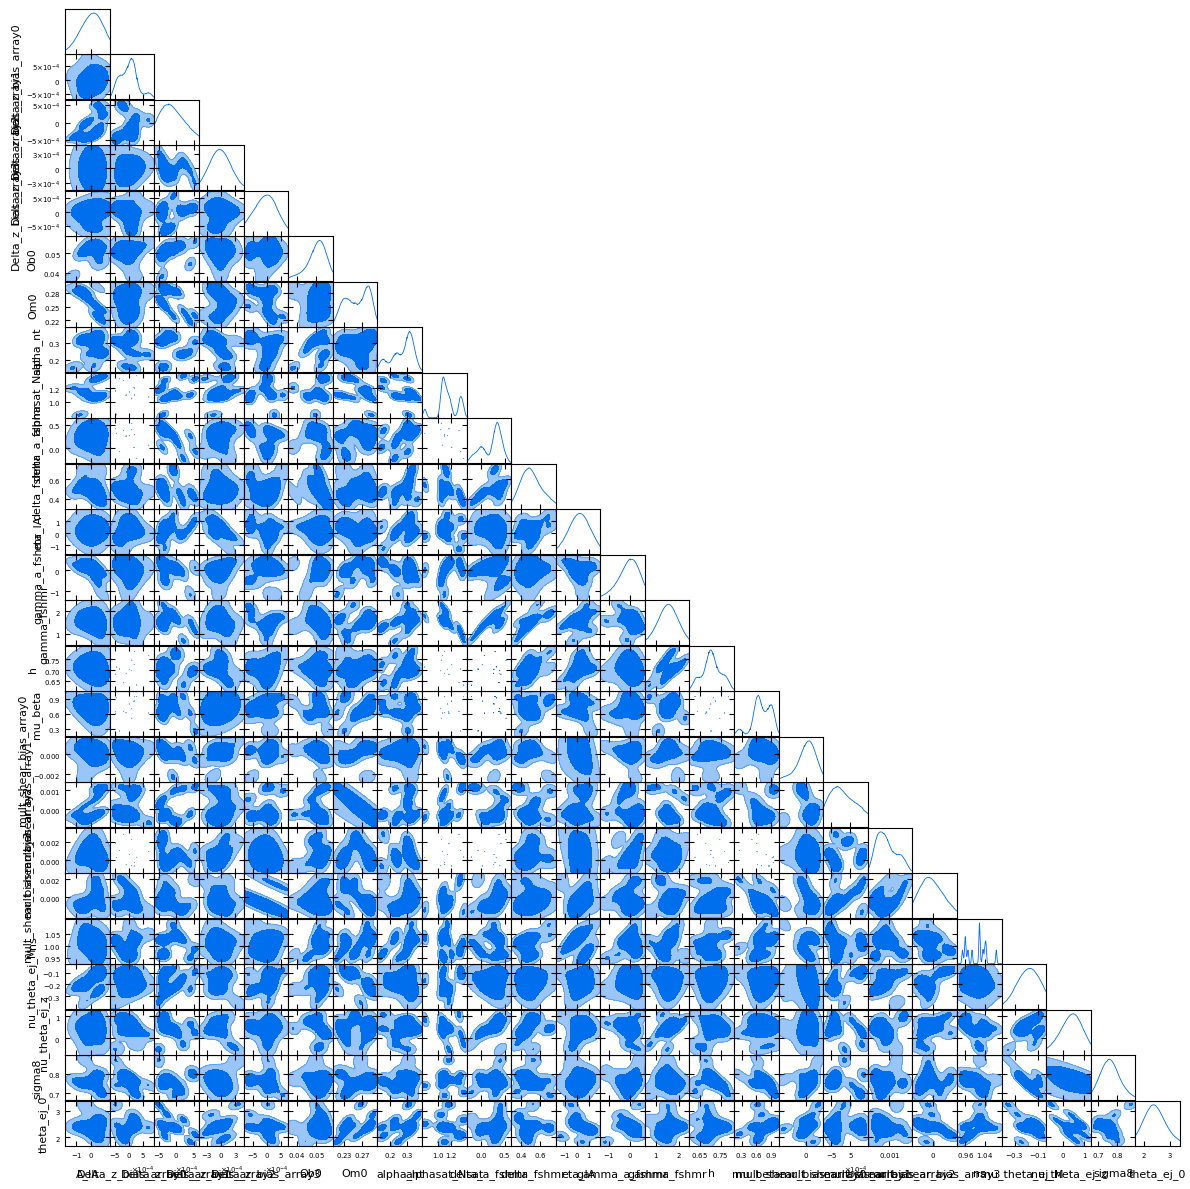

In [32]:
g = plots.get_subplot_plotter(width_inch=12)
g.triangle_plot([samples], filled=True)
# g.triangle_plot([samples], filled=True)




In [21]:
import pickle as pk
import dill as dill
import numpy as np
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
%matplotlib inline
import os

import getdist
from getdist import plots, MCSamples




def get_MCsamps(fname, param_acorr='sigma8', acorr_min=0.0, acorr_max = 0.05, nchains = 96, ind_frac_rm = 0.1, names=None, labels=None):
    df = pk.load(open(fname,'rb'))
    sig8 = df[param_acorr]
    
    sig8_rs = sig8.reshape(nchains,-1)
    # print(sig8_rs.shape)
    from numpyro.diagnostics import autocorrelation, autocovariance
    
    acorr = autocorrelation(sig8_rs, axis=1)
    ind_del = []
    for ji in range(acorr.shape[0]):
        if (np.std(acorr[ji,100:]) > acorr_max) or (np.std(acorr[ji,100:]) < acorr_min):
            ind_del.append(ji)    
    
    samps = []
    keys = []
    for key in df:
        if ('base' not in key) and ('decentered' not in key):
            if key not in ['RUN_SETTINGS', 'diverging', 'potential_energy']:
            # if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'fiducial_other_params', 'fiducial_halo_params', 'fiducial_analysis_params', 'diverging', 'potential_energy']:
                if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
                    for jb in range(4):
                        samps.append(df[key][:, jb])
                        keys.append(key + '_' + str(jb))
                        # print(df[key][:, jb].shape)
                # print(samps[0].shape)
                # print(df[key].shape)
                else:
                    samps.append(df[key])
                    keys.append(key)
    
    samps = np.array(samps).T
    ind_sigma8 = keys.index('sigma8')
    # ind_thetaejM = keys.index('nu_theta_ej_M')
    ind_Om = keys.index('Om0')
    samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5
    
    samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
    keys.append('S8')
    
    import getdist
    from getdist import plots, MCSamples
    
    if names is None:
        names = keys
        indsel_names = np.arange(len(names))
    else:
        indsel_names = []
        for name in names:
            indsel_names.append(keys.index(name))
    
    
    save_plot_dir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
    labels_all = {'A_IA':r'$A_{\rm IA}$',
     'Ob0':r'$\Omega_b$',
     'Om0':r'$\Omega_{\rm m}$',
     'eta_IA':r'$\eta_{\rm IA}$',
     'log10_Mc0':r'$\log(M_c)$',
     'theta_co_0':r'$\theta_{\rm co, 0}$',
     'gamma_rhogas':r'$\gamma$',
     'nu_z':r'$\nu_z$',
     'h':r'$h$',
     'ns':r'$n_s$',
     'mu_beta':r'$\mu_{\beta}$',
     'nu_theta_ej_M':r'$\nu^{M}_{\theta_{\rm ej}}$',
     'nu_theta_ej_z':r'$\nu^{z}_{\theta_{\rm ej}}$',
     'nu_theta_co_z':r'$\nu^{z}_{\theta_{\rm co}}$', 
     'log10_Mc0':r'$\log(M_c)$',
        'delta_rhogas':r'$\delta$',
        'gamma_rhogas':r'$\gamma$',
     'sigma8':r'$\sigma_8$',
     'theta_ej_0':r'$\theta_{\rm ej, 0}$',
     'S8':r'$S_8$',
     'alpha_nt':r'$\alpha_{\rm nt}$',
     'alpha_ky':r'$\alpha_{\rm ky}$',
     'alpha_kk':r'$\alpha_{\rm kk}$',
    'Delta_z_bias_array_0':r'$\Delta z_1$',
     'Delta_z_bias_array_1':r'$\Delta z_2$',
     'Delta_z_bias_array_2':r'$\Delta z_3$',
     'Delta_z_bias_array_3':r'$\Delta z_4$',
     'mult_shear_bias_array_0':r'$m_1$',
     'mult_shear_bias_array_1':r'$m_2$',
     'mult_shear_bias_array_2':r'$m_3$',
     'mult_shear_bias_array_3':r'$m_4$'
    }
    
    if labels is None:
        labels = []
        
        for key in keys:
            if key in labels_all.keys():
                labels.append(labels_all[key])
            else:
                labels.append(r'm')
    
    
    # nchains = 80
    samps_sel = samps.reshape(nchains,-1, samps.shape[-1])
    nsamp_per_chain = samps_sel.shape[1]
    nrm = int(ind_frac_rm * nsamp_per_chain)
    samps_sel = samps_sel[:, nrm:, :]
    
    if len(ind_del) > 0:
        samps_sel = np.delete(samps_sel, ind_del, axis=0)
    else:
        samps_sel = samps_sel
    
    samps = samps_sel.reshape(-1, samps_sel.shape[-1])
    print(samps.shape, samps_sel.shape)
    from numpyro.diagnostics import gelman_rubin, effective_sample_size, print_summary
    ind_gr = ind_sigma8
    gr = gelman_rubin(samps[:, ind_gr].reshape(samps_sel.shape[0], -1))
    print(gr)
    
    samples = MCSamples(samples=samps[:,indsel_names],names = names, labels = labels)
    marge = samples.getMargeStats()
    # for j1 in range(len(names)):
        # paramj1 = names[j1]
        # r_marge = marge.parWithName(paramj1)
        # r_mean = r_marge.mean
        # print(paramj1 + ': ' + str(r_mean) + ', ' + str(r_mean - r_marge.limits[0].lower) + ', ' + str(r_marge.limits[0].upper -  r_mean))

    return samples




In [27]:
# ldir = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/chains_Apr/'
# samps_all = get_MCsamps(ldir + 'mcmc_v1_test.pkl')
# 
ldir = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/chains_july_v5'
probe= 'kk_gg_gk_ge'
lmax = 1000
samps_notSZ_8000 = get_MCsamps(f'{ldir}/{probe}/mcmc_v5_{probe}_scval_{lmax}_samples_4000_warmup_3000_num_chains_96_treedepth_4.pkl')

probe= 'ky_kk_gg_gy_gk_ge'
lmax = 1000
samps_wtSZ_8000 = get_MCsamps(f'{ldir}/{probe}/mcmc_v5_{probe}_scval_{lmax}_samples_4000_warmup_3000_num_chains_96_treedepth_4.pkl')




(111600, 29) (31, 3600, 29)
1.0258368813490104
Removed no burn in
(50400, 29) (14, 3600, 29)
1.0410630586800322
Removed no burn in


<Figure size 625x625 with 0 Axes>

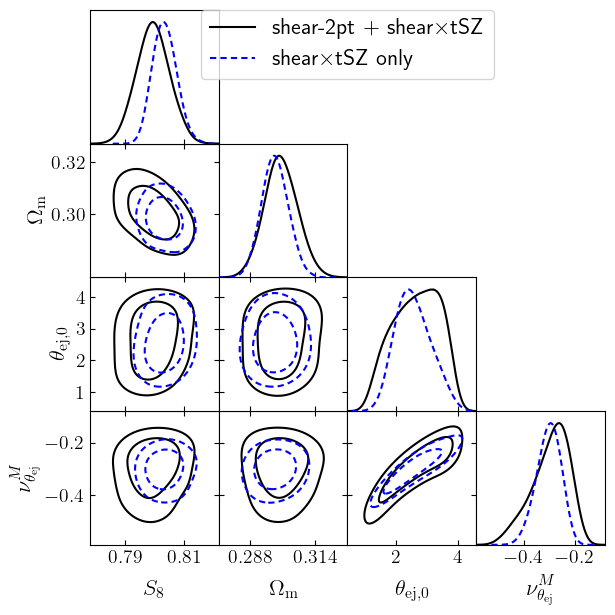

In [28]:
# params = ['Om0', 'theta_ej_0', 'nu_theta_ej_M',  'nu_theta_ej_z',  'mu_beta','A_IA', 'eta_IA', 'sigma8', 'alpha_ky', 'S8']
# params = ['Om0','A_IA', 'eta_IA', 'sigma8',  'S8', 'h', 'ns', 'Ob0','mult_shear_bias_array_3',  'Delta_z_bias_array_3']
g = plots.getSinglePlotter(width_inch=6.25, ratio=1.0)
# g.settings.auto_ticks = True
g.settings.axes_fontsize   = 18
g.settings.lab_fontsize    = 20
g.settings.legend_fontsize = 20
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 2

line_args = [{'lw':1.0,'color':'black'},{'lw':1.0, 'ls':'--' ,'color':'blue'},{'lw':1.0,'color':'red'},{'lw':0.1,'color':'orange'},{'lw':0.1,'color':'green'}]

contour_args = {'filled': True, 'alpha': 0.7}


# samps_all = get_MCsamps(ldir + 'mcmc_v10_widemuej_nzfix_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_8000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')
# samps_gty = get_MCsamps(ldir + 'mcmc_v10_widemuej_nzfix_probe_gty_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_8000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')
# samps_xipm = get_MCsamps(ldir + 'mcmc_v10_widemuej_nzfix_probe_xip_xim_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_8000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')
params = samps_all.getParamNames().getRunningNames()
# g = plots.get_subplot_plotter(width_inch=8)
g.triangle_plot([samps_notSZ_8000, samps_wtSZ_8000], ['S8', 'Om0', 'theta_ej_0', 'nu_theta_ej_M'], line_args=line_args, 
            contour_lws=[1.5, 1.5, 1.0], filled = [False, False,True, True, True], contour_colors = ['black','blue','red','orange','green'],
            ls=['-','--','','',''], legend_labels = [r'shear-2pt + shear$\times$tSZ',r'shear$\times$tSZ only',r'shear-2pt only'])
# save_plot_dir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# g.export(save_plot_dir  + 'contour_Om0_S8_nuejM_internal.pdf')
import matplotlib
%matplotlib inline
pl.show()





In [ ]:
import arviz as az

az.style.use("arviz-darkgrid")

axes = az.plot_pair(
    s,
    kind=["scatter", "kde"],
    # var_names=['Om0', 'sigma8',  'theta_ej_0', 'nu_theta_ej_M', 'nu_theta_ej_z'],
    var_names=['Om0', 'sigma8', 'Ob0', 'ns', 'h', 'theta_ej_0', 'nu_theta_ej_M', 'nu_theta_ej_z', 'A_IA', 'eta_IA'],
    # var_names=['theta_ej_0', 'nu_theta_ej_M', 'nu_theta_ej_z'],
    kde_kwargs={
        "hdi_probs": [0.3, 0.6, 0.9],  # Plot 30%, 60% and 90% HDI contours
        "contourf_kwargs": {"cmap": "Blues"},
    },
    marginals=True,
    point_estimate="median",
);